# LambdaLLG initial-state relaxation examples

This notebook uses the `InitialStates.jl` helpers to seed common magnetic textures,
relax them with the LLG solver, and inspect the resulting stable configurations.

The examples cover:

1. A 1D Neel domain wall relaxed with bulk DMI.
2. A 1D Bloch domain wall relaxed with bulk DMI.
3. A 2D Bloch skyrmion relaxed with bulk DMI.
4. A 2D Neel skyrmion relaxed with interfacial DMI.
5. A two-domain-wall example.
6. A two-skyrmion example.
7. A straight 2D Bloch wall relaxed with bulk DMI.
8. A straight tilted 2D Neel wall relaxed with interfacial DMI.


In [1]:
using Pkg; Pkg.activate("../")


  Activating project at `C:\Users\freye\PersonalCode\LambdaLLG.jl`


In [2]:
using LambdaLLG
using LinearAlgebra
using Statistics
import PyPlot as plt


## Helpers

The line plots follow the package plotting convention: blue, green, red for
`m_x`, `m_y`, `m_z`. Density plots use `pcolormesh` on the final `m_z` map,
with in-plane arrows showing the wall or skyrmion chirality.


In [3]:
spin_at(spins::AbstractArray{<:Real, 2}, center::Real) = collect(spins[:, Int(round(center))])
spin_at(spins::AbstractArray{<:Real, 3}, center) = collect(spins[:, Int(round(center[1])), Int(round(center[2]))])

function wall_seed1D(Nx; center=(Nx + 1) / 2, width=6.0, wall_type=:bloch, reference_axis=(1.0, 0.0, 0.0), easy_axis=(0.0, 0.0, 1.0), chirality=1.0, polarity=1.0)
    spins = uniform_state1D(Nx; direction=easy_axis)
    easy = normalize(collect(easy_axis))
    ref = normalize(collect(reference_axis))
    neel_axis = ref .- dot(ref, easy) .* easy
    neel_axis ./= norm(neel_axis)
    bloch_axis = cross(easy, neel_axis)
    bloch_axis ./= norm(bloch_axis)
    transverse_axis = wall_type == :neel ? neel_axis : wall_type == :bloch ? bloch_axis : error("wall_type must be :neel or :bloch")

    for i in 1:Nx
        xi = (i - center) / width
        profile = polarity * tanh(xi) .* easy .+ chirality * sech(xi) .* transverse_axis
        spins[:, i] .+= profile .- easy
    end

    normalize_spins!(spins)
    return spins
end

function paint_skyrmion_seed!(spins; center=((size(spins, 2) + 1) / 2, (size(spins, 3) + 1) / 2), radius=10.0, width=3.0, skyrmion_type=:neel, chirality=1.0, polarity=-1.0, amplitude=1.0)
    easy_axis = [0.0, 0.0, 1.0]
    x0, y0 = center

    for j in axes(spins, 3), i in axes(spins, 2)
        dx = i - x0
        dy = j - y0
        r = hypot(dx, dy)
        mz = polarity * tanh((radius - r) / width)
        mxy = sqrt(max(0.0, 1.0 - mz^2))

        if r < 1e-12
            profile = [0.0, 0.0, mz]
        elseif skyrmion_type == :neel
            profile = [chirality * mxy * dx / r, chirality * mxy * dy / r, mz]
        elseif skyrmion_type == :bloch
            profile = [-chirality * mxy * dy / r, chirality * mxy * dx / r, mz]
        else
            error("skyrmion_type must be :neel or :bloch")
        end

        spins[:, i, j] .+= amplitude .* (profile .- easy_axis)
    end

    return spins
end

function wall_summary(spins)
    center = argmin(abs.(spins[3, :]))
    return (
        center = center,
        center_spin = collect(spins[:, center]),
        mean_abs_mx = mean(abs.(spins[1, :])),
        mean_abs_my = mean(abs.(spins[2, :])),
    )
end

function core_radius(spins; threshold=0.0)
    return sqrt(count(<(threshold), spins[3, :, :]) / pi)
end

function texture_summary(spins)
    center = ((size(spins, 2) + 1) / 2, (size(spins, 3) + 1) / 2)
    return (
        center_spin = spin_at(spins, center),
        core_radius = core_radius(spins),
        mean_abs_mx = mean(abs.(spins[1, :, :])),
        mean_abs_my = mean(abs.(spins[2, :, :])),
    )
end

function wall_normal_sample(spins; point, slope, offset=10.0)
    x0, y0 = point
    nx, ny = isinf(slope) ? (1.0, 0.0) : (-slope / sqrt(1 + slope^2), 1.0 / sqrt(1 + slope^2))
    minus = (clamp(Int(round(x0 - offset * nx)), 1, size(spins, 2)), clamp(Int(round(y0 - offset * ny)), 1, size(spins, 3)))
    plus = (clamp(Int(round(x0 + offset * nx)), 1, size(spins, 2)), clamp(Int(round(y0 + offset * ny)), 1, size(spins, 3)))
    crossing = (clamp(Int(round(x0)), 1, size(spins, 2)), clamp(Int(round(y0)), 1, size(spins, 3)))
    return (minus = minus, crossing = crossing, plus = plus)
end

function wall2d_summary(spins; point, slope, offset=10.0)
    samples = wall_normal_sample(spins; point=point, slope=slope, offset=offset)
    return (
        minus = spin_at(spins, samples.minus),
        crossing = spin_at(spins, samples.crossing),
        plus = spin_at(spins, samples.plus),
    )
end

function plot_chain!(ax, spins; title="")
    sites = collect(axes(spins, 2))
    ax.plot(sites, spins[1, :], color="blue", label="m_x")
    ax.plot(sites, spins[2, :], color="green", label="m_y")
    ax.plot(sites, spins[3, :], color="red", label="m_z")
    ax.set_xlabel("site")
    ax.set_ylabel("spin component")
    ax.set_ylim(-1.05, 1.05)
    ax.set_title(title)
    ax.grid(true, alpha=0.25)
    return nothing
end

function plot_texture!(ax, spins; stride=4, title="")
    mz = spins[3, :, :]
    Nx, Ny = size(spins, 2), size(spins, 3)
    xs = 1:stride:Nx
    ys = 1:stride:Ny
    X = [i for j in ys, i in xs]
    Y = [j for j in ys, i in xs]
    U = [spins[1, i, j] for j in ys, i in xs]
    V = [spins[2, i, j] for j in ys, i in xs]

    im = ax.pcolormesh(mz', cmap="RdBu_r", vmin=-1, vmax=1, shading="nearest")
    ax.quiver(X, Y, U, V, color="lightgreen", pivot="mid", scale=20, linewidth=2)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    return im
end

function two_domain_wall_seed(Nx; centers=(55.0, 107.0), width=6.0, wall_type=:bloch, reference_axis=(1.0, 0.0, 0.0))
    easy_axis = [0.0, 0.0, 1.0]
    ref_axis = normalize(collect(reference_axis))
    neel_axis = ref_axis .- dot(ref_axis, easy_axis) .* easy_axis
    neel_axis ./= norm(neel_axis)
    bloch_axis = cross(easy_axis, neel_axis)
    bloch_axis ./= norm(bloch_axis)
    transverse_axis = wall_type == :neel ? neel_axis : wall_type == :bloch ? bloch_axis : error("wall_type must be :neel or :bloch")

    c1, c2 = centers
    spins = zeros(3, Nx)
    for i in 1:Nx
        xi1 = (i - c1) / width
        xi2 = (i - c2) / width
        mz = tanh(xi1) * tanh(xi2)
        mperp = sech(xi1) - sech(xi2)
        spins[:, i] .= mz .* easy_axis .+ mperp .* transverse_axis
    end
    normalize_spins!(spins)
    return spins
end


two_domain_wall_seed (generic function with 1 method)

## 1. Relax a Neel wall in 1D with bulk DMI

In this parameter set the bulk DMI term favors a Bloch wall. Starting from a
Neel seed shows the relaxation toward that stable chirality.


In [4]:
Nx1 = 121
x0 = (Nx1 + 1) / 2
J1 = 1.0
K1 = (0.0, 0.0, 0.35)
alpha1 = 0.25
D1 = (0.3, 0.0, 0.0)
tspan1 = (0.0, 120.0)

p_wall = LLGParams1D(Nx1, J1, K1, (0.0, 0.0, 0.0), alpha1; D=D1)


LLGParams1D(121, 1.0, (0.3, 0.0, 0.0), (0.0, 0.0, 0.35), (0.0, 0.0, 0.0), 0.25, 0.0, 0.0, Int64[], Array{Float64, 3}(undef, 3, 3, 0), LambdaLLG.LLGFields1D([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]), false, false, 0.0, Int64[], Array{Float64, 4}(undef, 2, 3, 3, 0))

(initial = (center = 61, center_spin = [1.0, 0.0, 0.0], mean_abs_mx = 0.1557731785291997, mean_abs_my = 0.0), relaxed = (center = 72, center_spin = [0.0012250061453585427, 0.9777290860360797, -0.20986741928893185], mean_abs_mx = 6.620458973210933e-5, mean_abs_my = 0.05899565306062445))

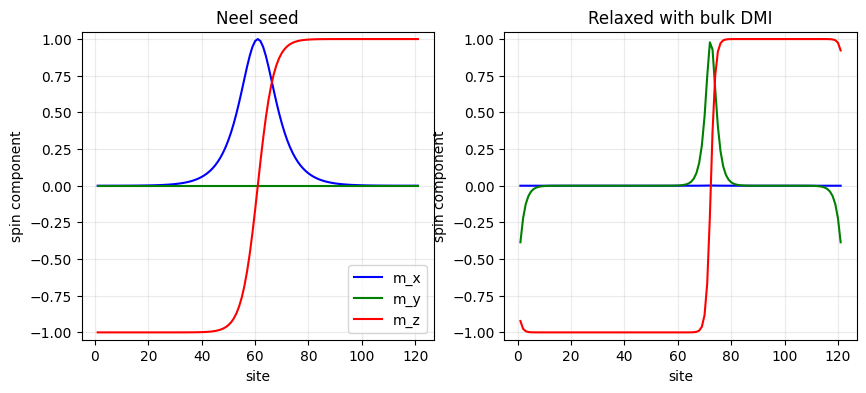

PyObject <matplotlib.legend.Legend object at 0x0000013CA5FE9490>

In [5]:
s_neel0 = wall_seed1D(Nx1; center=x0, width=6.0, wall_type=:neel, reference_axis=(1.0, 0.0, 0.0))

sol_neel = evolve1D(copy(s_neel0), tspan1, p_wall; reltol=1e-6, abstol=1e-6)
s_neel = reshape(copy(sol_neel.u[end]), 3, Nx1)

display((initial = wall_summary(s_neel0), relaxed = wall_summary(s_neel)))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_chain!(ax[1], s_neel0; title="Neel seed")
plot_chain!(ax[2], s_neel; title="Relaxed with bulk DMI")
ax[1].legend(loc="lower right")


## 2. Relax a Bloch wall in 1D with bulk DMI

The same relaxation started from a Bloch seed should stay close to the stable
domain-wall manifold selected by the same Hamiltonian.


(initial = (center = 61, center_spin = [0.0, 1.0, 0.0], mean_abs_mx = 0.0, mean_abs_my = 0.1557731785291997), relaxed = (center = 61, center_spin = [6.84587220668503e-15, 1.0, -1.1959490508055558e-14], mean_abs_mx = 3.9541096307553115e-6, mean_abs_my = 0.05899645353598338))

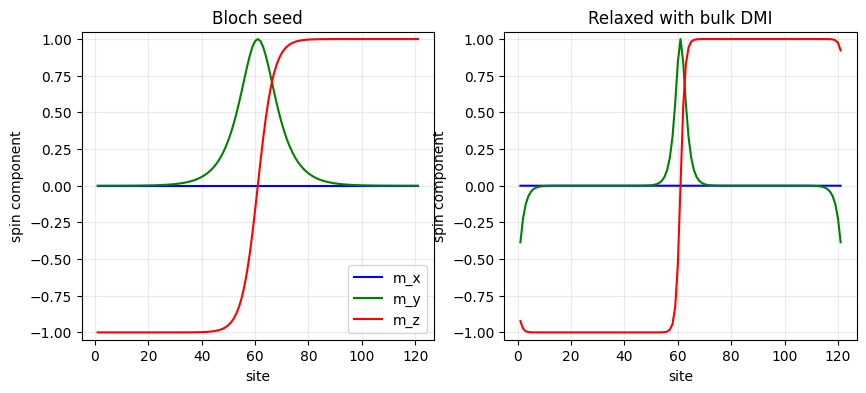

PyObject <matplotlib.legend.Legend object at 0x0000013CA6033950>

In [6]:
s_bloch0 = wall_seed1D(Nx1; center=x0, width=6.0, wall_type=:bloch, reference_axis=(1.0, 0.0, 0.0))

sol_bloch_wall = evolve1D(copy(s_bloch0), tspan1, p_wall; reltol=1e-6, abstol=1e-6)
s_bloch_wall = reshape(copy(sol_bloch_wall.u[end]), 3, Nx1)

display((initial = wall_summary(s_bloch0), relaxed = wall_summary(s_bloch_wall)))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_chain!(ax[1], s_bloch0; title="Bloch seed")
plot_chain!(ax[2], s_bloch_wall; title="Relaxed with bulk DMI")
ax[1].legend(loc="lower right")


## 3. Relax a Bloch skyrmion in 2D with bulk DMI

On the square lattice, bulk DMI is represented by bond-parallel Moriya vectors,
`D = ((D, 0, 0), (0, D, 0))`. This favors a Bloch skyrmion.


(initial = (center_spin = [0.0, 0.0, -1.0], core_radius = 9.853147481188747, mean_abs_mx = 0.034626055477898515, mean_abs_my = 0.03462605547789853), relaxed = (center_spin = [2.7635306479234596e-13, -8.627791766778525e-13, -1.0], core_radius = 9.91754782346883, mean_abs_mx = 0.029472504373782578, mean_abs_my = 0.029472504373766053))

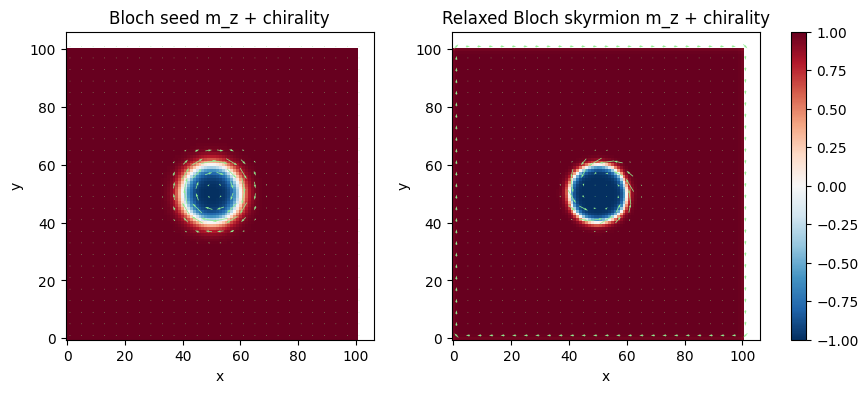

PyObject <matplotlib.colorbar.Colorbar object at 0x0000013C9D0E43D0>

In [7]:
Nx2, Ny2 = 101, 101
J2 = 1.0
alpha2 = 0.3
tspan2 = (0.0, 120.0)

K_bulk = (0.0, 0.0, 0.45)
D_bulk = ((0.25, 0.0, 0.0), (0.0, 0.25, 0.0))

s_bloch_sk0 = uniform_state2D(Nx2, Ny2; direction=(0.0, 0.0, 1.0))
paint_skyrmion_seed!(s_bloch_sk0; center=((Nx2 + 1) / 2, (Ny2 + 1) / 2), radius=10.0, width=2.8, skyrmion_type=:bloch, chirality=-1.0, polarity=-1.0)
normalize_spins!(s_bloch_sk0)

p_bulk = LLGParams2D(Nx2, Ny2, J2, K_bulk, (0.0, 0.0, 0.0), alpha2; D=D_bulk)
sol_bloch_sk = evolve2D(copy(s_bloch_sk0), tspan2, p_bulk; reltol=1e-6, abstol=1e-6)
s_bloch_sk = reshape(copy(sol_bloch_sk.u[end]), 3, Nx2, Ny2)

display((initial = texture_summary(s_bloch_sk0), relaxed = texture_summary(s_bloch_sk)))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_texture!(ax[1], s_bloch_sk0; title="Bloch seed m_z + chirality")
im = plot_texture!(ax[2], s_bloch_sk; title="Relaxed Bloch skyrmion m_z + chirality")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


## 4. Relax a Neel skyrmion in 2D with interfacial DMI

For interfacial DMI we use

`D = ((0, D, 0), (-D, 0, 0))`,

which favors a Neel skyrmion on the square lattice.


(initial = (center_spin = [0.0, 0.0, -1.0], core_radius = 9.853147481188747, mean_abs_mx = 0.03462605547789853, mean_abs_my = 0.034626055477898515), relaxed = (center_spin = [-6.932286280448737e-13, -1.1421712819262316e-12, -1.0], core_radius = 21.38717621487482, mean_abs_mx = 0.09477708192754335, mean_abs_my = 0.0947770819275447))

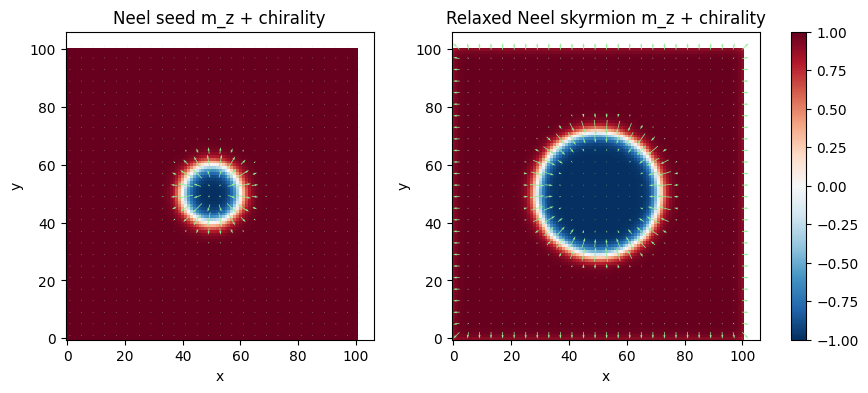

PyObject <matplotlib.colorbar.Colorbar object at 0x0000013CB082AED0>

In [8]:
K_int = (0.0, 0.0, 0.15)
D_int = ((0.0, 0.2, 0.0), (-0.2, 0.0, 0.0))

s_neel_sk0 = uniform_state2D(Nx2, Ny2; direction=(0.0, 0.0, 1.0))
paint_skyrmion_seed!(s_neel_sk0; center=((Nx2 + 1) / 2, (Ny2 + 1) / 2), radius=10.0, width=2.8, skyrmion_type=:neel, chirality=1.0, polarity=-1.0)
normalize_spins!(s_neel_sk0)

p_int = LLGParams2D(Nx2, Ny2, J2, K_int, (0.0, 0.0, 0.0), alpha2; D=D_int)
sol_neel_sk = evolve2D(copy(s_neel_sk0), tspan2, p_int; reltol=1e-6, abstol=1e-6)
s_neel_sk = reshape(copy(sol_neel_sk.u[end]), 3, Nx2, Ny2)

display((initial = texture_summary(s_neel_sk0), relaxed = texture_summary(s_neel_sk)))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_texture!(ax[1], s_neel_sk0; title="Neel seed m_z + chirality")
im = plot_texture!(ax[2], s_neel_sk; title="Relaxed Neel skyrmion m_z + chirality")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


## 5. Two-domain-wall example

A wall pair imposes an alternating domain sequence, so here we seed the pair
with an explicit product profile and then relax it with the same 1D bulk-DMI
parameters used above.


(left_seed = [0.0, 1.0, 0.0], right_seed = [0.0, -1.0, 0.0], left_relaxed = [-3.5389682310837824e-5, -2.4180800673541918e-5, -0.9999999990814297], right_relaxed = [3.5389682310837824e-5, 2.4180800673541918e-5, -0.9999999990814297], edge_spins = (left = [-9.212808383317195e-5, 0.3858723633204504, 0.9225521723663689], right = [9.212808383317195e-5, -0.3858723633204504, 0.9225521723663689]))

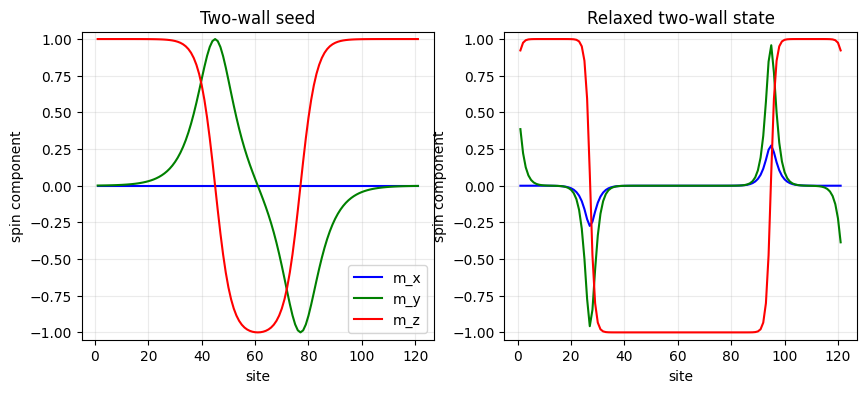

PyObject <matplotlib.legend.Legend object at 0x0000013CBB066450>

In [9]:
pair_centers = (45.0, 77.0)
s_pair0 = two_domain_wall_seed(Nx1; centers=pair_centers, width=6.0, wall_type=:bloch, reference_axis=(1.0, 0.0, 0.0))

sol_pair = evolve1D(copy(s_pair0), tspan1, p_wall; reltol=1e-6, abstol=1e-6)
s_pair = reshape(copy(sol_pair.u[end]), 3, Nx1)

display((
    left_seed = spin_at(s_pair0, pair_centers[1]),
    right_seed = spin_at(s_pair0, pair_centers[2]),
    left_relaxed = spin_at(s_pair, pair_centers[1]),
    right_relaxed = spin_at(s_pair, pair_centers[2]),
    edge_spins = (left = collect(s_pair[:, 1]), right = collect(s_pair[:, end])),
))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_chain!(ax[1], s_pair0; title="Two-wall seed")
plot_chain!(ax[2], s_pair; title="Relaxed two-wall state")
ax[1].legend(loc="lower right")


## 6. Two-skyrmion example

Because the skyrmion painters are localized, a multi-skyrmion state can be built
directly by repeated calls before the final normalization.


(first_seed = [-0.00020238075705287988, 0.0, -0.9999999795210144], second_seed = [0.00020238075705287988, 0.0, -0.9999999795210144], first_relaxed = [-0.04218708309223113, -0.03520899175197679, -0.9984891471217794], second_relaxed = [0.042187083093290646, 0.035208991752536216, -0.9984891471217149], relaxed_radius = 23.357721312641292)

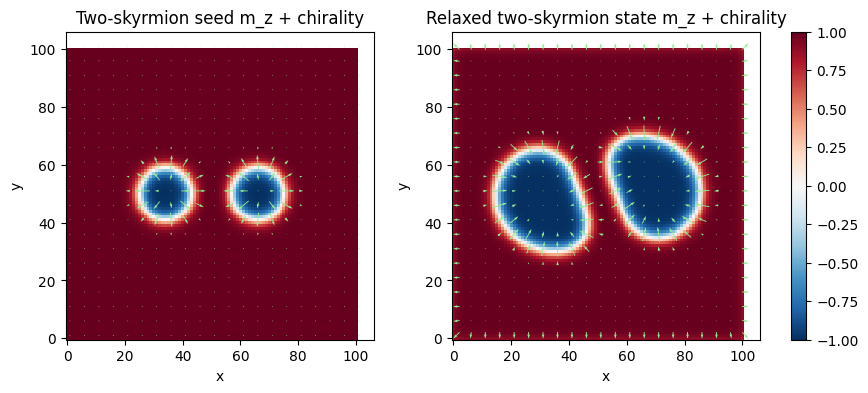

PyObject <matplotlib.colorbar.Colorbar object at 0x0000013CC3417E90>

In [10]:
pair_centers_2d = ((35.0, 51.0), (67.0, 51.0))
s_two_sk0 = uniform_state2D(Nx2, Ny2; direction=(0.0, 0.0, 1.0))
paint_skyrmion_seed!(s_two_sk0; center=pair_centers_2d[1], radius=9.0, width=2.5, skyrmion_type=:neel, chirality=1.0, polarity=-1.0)
paint_skyrmion_seed!(s_two_sk0; center=pair_centers_2d[2], radius=9.0, width=2.5, skyrmion_type=:neel, chirality=1.0, polarity=-1.0)
normalize_spins!(s_two_sk0)

sol_two_sk = evolve2D(copy(s_two_sk0), tspan2, p_int; reltol=1e-6, abstol=1e-6)
s_two_sk = reshape(copy(sol_two_sk.u[end]), 3, Nx2, Ny2)

display((
    first_seed = spin_at(s_two_sk0, pair_centers_2d[1]),
    second_seed = spin_at(s_two_sk0, pair_centers_2d[2]),
    first_relaxed = spin_at(s_two_sk, pair_centers_2d[1]),
    second_relaxed = spin_at(s_two_sk, pair_centers_2d[2]),
    relaxed_radius = core_radius(s_two_sk),
))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_texture!(ax[1], s_two_sk0; stride=5, title="Two-skyrmion seed m_z + chirality")
im = plot_texture!(ax[2], s_two_sk; stride=5, title="Relaxed two-skyrmion state m_z + chirality")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


## 7. Straight 2D Bloch wall example

A straight Bloch wall can be built by starting from a uniform state, painting
the wall in place, and then relaxing it. Here the wall front is horizontal and
crosses the center of the sample.


(initial = (minus = [0.0, 0.16307123192997783, -0.9866142981514303], crossing = [0.0, 1.0, 0.0], plus = [0.0, 0.16307123192997783, 0.9866142981514303]), relaxed = (minus = [-3.033416282823224e-5, 8.12413854445889e-7, -0.9999999995395893], crossing = [-0.01080723139797379, -3.3009943785041425e-6, -0.9999416001640367], plus = [-0.8241438004028635, 0.0011660102290468341, 0.5663794105347322]))

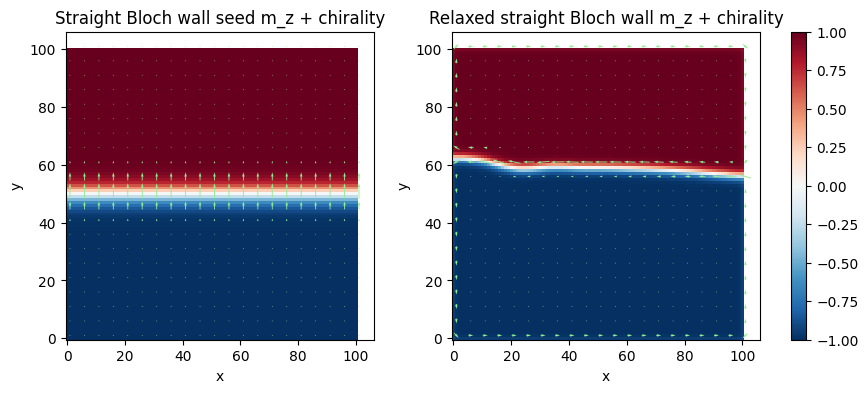

PyObject <matplotlib.colorbar.Colorbar object at 0x0000013CC34894D0>

In [11]:
K_wall2d = (0.0, 0.0, 0.35)
wall_point_bloch = ((Nx2 + 1) / 2, (Ny2 + 1) / 2)
s_wall2d_bloch0 = uniform_state2D(Nx2, Ny2; direction=(0.0, 0.0, 1.0))
paint_domain_wall!(s_wall2d_bloch0; point=wall_point_bloch, slope=0.0, width=4.0, wall_type=:bloch, reference_axis=(1.0, 0.0, 0.0))
normalize_spins!(s_wall2d_bloch0)

p_wall2d_bulk = LLGParams2D(Nx2, Ny2, J2, K_wall2d, (0.0, 0.0, 0.0), alpha2; D=D_bulk)
sol_wall2d_bloch = evolve2D(copy(s_wall2d_bloch0), tspan2, p_wall2d_bulk; reltol=1e-6, abstol=1e-6)
s_wall2d_bloch = reshape(copy(sol_wall2d_bloch.u[end]), 3, Nx2, Ny2)

display((
    initial = wall2d_summary(s_wall2d_bloch0; point=wall_point_bloch, slope=0.0),
    relaxed = wall2d_summary(s_wall2d_bloch; point=wall_point_bloch, slope=0.0),
))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_texture!(ax[1], s_wall2d_bloch0; stride=5, title="Straight Bloch wall seed m_z + chirality")
im = plot_texture!(ax[2], s_wall2d_bloch; stride=5, title="Relaxed straight Bloch wall m_z + chirality")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


## 8. Straight tilted 2D Neel wall example

The same painter can seed a tilted front by specifying a slope and a crossing
point. This example uses interfacial DMI, which favors a Neel wall.


(initial = (minus = [0.15180728914913824, 0.0, -0.9884101107137614], crossing = [1.0, 0.0, 0.0], plus = [0.15180728914913824, 0.0, 0.9884101107137614]), relaxed = (minus = [0.08544756708822934, -0.14001436019986094, -0.9864556210071116], crossing = [0.029141928609557066, -0.047681912539702796, 0.9984373707015737], plus = [7.220636835190844e-5, -0.00011200160104927035, 0.9999999911209408]))

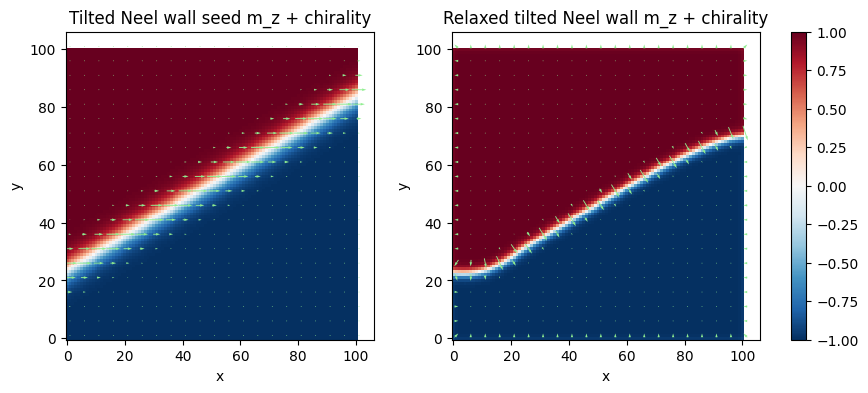

PyObject <matplotlib.colorbar.Colorbar object at 0x0000013CB0BD0050>

In [12]:
wall_point_neel = (45.0, 51.0)
wall_slope_neel = 0.6
s_wall2d_neel0 = uniform_state2D(Nx2, Ny2; direction=(0.0, 0.0, 1.0))
paint_domain_wall!(s_wall2d_neel0; point=wall_point_neel, slope=wall_slope_neel, width=4.0, wall_type=:neel, reference_axis=(1.0, 0.0, 0.0))
normalize_spins!(s_wall2d_neel0)

p_wall2d_int = LLGParams2D(Nx2, Ny2, J2, K_wall2d, (0.0, 0.0, 0.0), alpha2; D=D_int)
sol_wall2d_neel = evolve2D(copy(s_wall2d_neel0), tspan2, p_wall2d_int; reltol=1e-6, abstol=1e-6)
s_wall2d_neel = reshape(copy(sol_wall2d_neel.u[end]), 3, Nx2, Ny2)

display((
    initial = wall2d_summary(s_wall2d_neel0; point=wall_point_neel, slope=wall_slope_neel),
    relaxed = wall2d_summary(s_wall2d_neel; point=wall_point_neel, slope=wall_slope_neel),
))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_texture!(ax[1], s_wall2d_neel0; stride=5, title="Tilted Neel wall seed m_z + chirality")
im = plot_texture!(ax[2], s_wall2d_neel; stride=5, title="Relaxed tilted Neel wall m_z + chirality")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
